# ML Regression from Scratch - Notebook 1: Linear Regression (Single Feature)

**Goal:** predict a student's `CapstoneScore` from their `TotalHours` (hours studied) using
**simple linear regression built entirely from scratch** with NumPy and Pandas - no scikit-learn anywhere in this notnotebook.


1. Load and explore the data
2. Derive the maths (hypothesis, cost, gradients) from first principles
3. Implement `compute_cost`, `compute_gradients`, `gradient_descent`, `predict`
4. Run gradient descent with **4 different learning rates** and study convergence
5. Evaluate the final model with MSE, MAE, RMSE and R²

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Load & explore the data

The raw dataset has one row per student per course. Each row records
attendance, hours studied, assignments completed, hackathon participation,
GitHub/peer-review scores and the final `CapstoneScore`.

In [61]:
df = pd.read_csv('student scores.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (150, 10)


,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
3,Nisal Gamage,1,74.5,63.9,7,0,76.8,1.7,Production-Ready ML Systems,100.0
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1


In [62]:
df.describe()

,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CapstoneScore
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,2.060000,77.834667,52.562667,5.806667,0.446667,52.996667,2.972667,62.137333
std,0.837302,11.400547,26.689184,2.579466,0.498813,30.020609,1.189264,24.782909
min,1.000000,60.400000,10.500000,2.000000,0.000000,0.600000,1.000000,22.000000
25%,1.000000,68.200000,29.325000,4.000000,0.000000,26.000000,1.900000,41.425000
50%,2.000000,76.850000,50.300000,6.000000,0.000000,58.100000,2.900000,54.950000
75%,3.000000,86.475000,77.475000,8.000000,1.000000,78.450000,3.900000,83.500000
max,3.000000,99.900000,98.800000,10.000000,1.000000,99.500000,5.000000,100.000000


We restrict ourselves to a single course so that the relationship between
total hours studied and the capstone score is not confounded by different
course difficulties.

In [63]:
df = df[df['CourseName'] == 'Foundations of ML'].reset_index(drop=True)  #reset the row numbers
print(f"Rows after filtering to 'Foundations of ML': {len(df)}")
df.head()

Rows after filtering to 'Foundations of ML': 72


,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
3,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1
4,Chamath Perera,3,86.5,88.0,5,0,23.9,1.3,Foundations of ML,68.2


## 2. Select the feature and target

For this notebook the single feature is `total_hours` → the `TotalHours`
column (hours the student spent studying), and the target is `CapstoneScore`.

In [64]:
X = df['TotalHours'].values.astype(float)   # shape (m,)
Y = df['CapstoneScore'].values.astype(float) # shape (m,)

print(f"X (TotalHours) -> min: {X.min():.1f}, max: {X.max():.1f}, mean: {X.mean():.2f}")
print(f"Y (CapstoneScore) -> min: {Y.min():.1f}, max: {Y.max():.1f}, mean: {Y.mean():.2f}")

X (TotalHours) -> min: 10.5, max: 98.8, mean: 56.13
Y (CapstoneScore) -> min: 23.3, max: 89.3, mean: 55.11


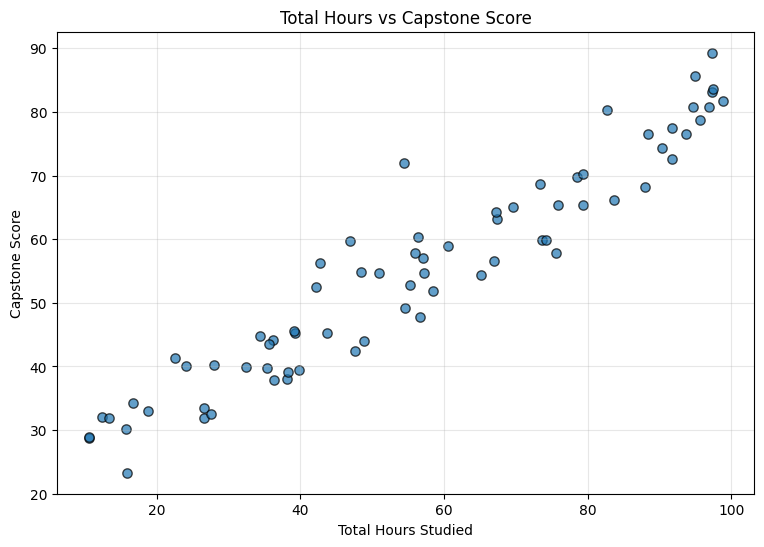

In [65]:
plt.figure(figsize=(9, 6))
plt.scatter(X, Y, s=45, alpha=0.7, edgecolor='k')
plt.xlabel('Total Hours Studied')
plt.ylabel('Capstone Score')
plt.title('Total Hours vs Capstone Score')
plt.grid(alpha=0.3)
plt.show()

There is a visible upward trend - students who study more hours tend to
score higher - but there is a lot of scatter, so we expect a fairly modest R².

## 3. Train / test split (from scratch)

We never import `train_test_split` - we shuffle the row indices ourselves
with `np.random.permutation` and slice them 80/20.

In [66]:
def train_test_split_scratch(X, Y, test_size=0.2, seed=42):
    """
    Randomly split X, Y into train/test sets without any ML library.

    X, Y      : 1-D numpy arrays of the same length m
    test_size : fraction of samples to reserve for testing
    seed      : RNG seed so the split is reproducible

    Returns X_train, X_test, Y_train, Y_test
    """
    m = len(Y)
    rng = np.random.RandomState(seed)
    shuffled_idx = rng.permutation(m)

    n_test = int(m * test_size)
    test_idx = shuffled_idx[:n_test]
    train_idx = shuffled_idx[n_test:]

    return X[train_idx], X[test_idx], Y[train_idx], Y[test_idx]


X_train, X_test, Y_train, Y_test = train_test_split_scratch(X, Y, test_size=0.2, seed=42)
print(f"Train size: {len(Y_train)},  Test size: {len(Y_test)}")

Train size: 58,  Test size: 14


## 4. The maths, from absolute basics

**Hypothesis** (simple linear regression, one feature):

$$\hat{y}_i = \beta_0 + \beta_1 x_i$$

- $\beta_0$ is the intercept (predicted score when total hours studied = 0)
- $\beta_1$ is the slope (change in predicted score per additional hour studied)

**Cost function** - mean squared error, with the classic $\frac{1}{2m}$ scaling
so the derivative comes out clean:

$$J(\beta_0,\beta_1)=\frac{1}{2m}\sum_{i=1}^{m}(\hat y_i-y_i)^2$$

**Gradients** - partial derivatives of $J$ w.r.t. each parameter, found with
the chain rule ($\hat y_i$ depends on $\beta_0,\beta_1$):

$$\frac{\partial J}{\partial \beta_0}=\frac{1}{m}\sum_{i=1}^{m}(\hat y_i-y_i)
\qquad\qquad
\frac{\partial J}{\partial \beta_1}=\frac{1}{m}\sum_{i=1}^{m}(\hat y_i-y_i)x_i$$

**Parameter update** (gradient descent, learning rate $\alpha$):

$$\beta_0 := \beta_0 - \alpha\frac{\partial J}{\partial \beta_0}
\qquad\qquad
\beta_1 := \beta_1 - \alpha\frac{\partial J}{\partial \beta_1}$$

We repeat the update for `n_iterations`, each time moving $(\beta_0,\beta_1)$
a little further downhill on the cost surface.

### 4.1 `compute_cost`

In [67]:
def compute_cost(X, y, beta_0, beta_1):
    """
    Mean-squared-error cost for simple linear regression.

    X, y          : 1-D numpy arrays of length m (feature, target)
    beta_0, beta_1: current scalar parameters

    Returns a single float: J(beta_0, beta_1)
    """
    m = len(y)
    y_hat = beta_0 + beta_1 * X          # hypothesis, vectorised over all m rows
    cost = (1 / (2 * m)) * np.sum((y_hat - y) ** 2)
    return cost


# Sanity check with arbitrary parameters
test_cost = compute_cost(X_train, Y_train, beta_0=0.0, beta_1=0.0)
print(f"Cost at beta_0=0, beta_1=0: {test_cost:.4f}")

Cost at beta_0=0, beta_1=0: 1736.8466


### 4.2 `compute_gradients`

In [68]:
def compute_gradients(X, y, beta_0, beta_1):
    """
    Partial derivatives of the MSE cost w.r.t. beta_0 and beta_1.

    X, y          : 1-D numpy arrays of length m
    beta_0, beta_1: current scalar parameters

    Returns (d_beta0, d_beta1)
    """
    m = len(y)
    y_hat = beta_0 + beta_1 * X
    error = y_hat - y                    # (m,)

    d_beta0 = (1 / m) * np.sum(error)
    d_beta1 = (1 / m) * np.sum(error * X)
    return d_beta0, d_beta1


d0, d1 = compute_gradients(X_train, Y_train, beta_0=0.0, beta_1=0.0)
print(f"Gradients at beta_0=0, beta_1=0 -> d_beta0={d0:.4f}, d_beta1={d1:.4f}")

Gradients at beta_0=0, beta_1=0 -> d_beta0=-56.1586, d_beta1=-3662.5453


### 4.3 `gradient_descent`

Runs the update rule for a fixed number of iterations, recording the cost
(and the parameters) at every step so we can study convergence afterwards.
If a learning rate is too large the cost can explode to `inf`/`nan` - we
detect that and stop early rather than let the run crash.

In [69]:
def gradient_descent(X, y, learning_rate, n_iterations=1000, beta_0_init=0.0, beta_1_init=0.0, verbose=False):
    """
    Batch gradient descent for simple linear regression.

    X, y          : 1-D numpy arrays of length m
    learning_rate : alpha, the step size
    n_iterations  : maximum number of update steps
    beta_0_init, beta_1_init : starting parameters
    verbose       : if True, print cost every 10% of iterations

    Returns beta_0, beta_1, cost_history, n_completed
        cost_history : list of cost values, one per completed iteration
        n_completed  : how many iterations actually ran before stopping
                       (may be < n_iterations if the run diverged)
    """
    beta_0, beta_1 = beta_0_init, beta_1_init
    cost_history = []

    for i in range(n_iterations):
        cost = compute_cost(X, y, beta_0, beta_1)

        # Stop early if the run has diverged (learning rate too large)
        if not np.isfinite(cost):
            break

        cost_history.append(cost)

        d_beta0, d_beta1 = compute_gradients(X, y, beta_0, beta_1)
        beta_0 = beta_0 - learning_rate * d_beta0
        beta_1 = beta_1 - learning_rate * d_beta1

        if verbose and n_iterations >= 10 and i % (n_iterations // 10) == 0:
            print(f"  iter {i:>6} | cost = {cost:,.4f}")

    return beta_0, beta_1, cost_history, len(cost_history)

### 4.4 `predict`

In [70]:
def predict(X, beta_0, beta_1):
    """Vectorised prediction: y_hat = beta_0 + beta_1 * X"""
    return beta_0 + beta_1 * X


# Quick smoke test
beta_0_test, beta_1_test, hist_test, n_test = gradient_descent(X_train, Y_train, learning_rate=0.0001, n_iterations=500)
print(f"After 500 iterations @ lr=0.0001 -> beta_0={beta_0_test:.4f}, beta_1={beta_1_test:.4f}, final cost={hist_test[-1]:.4f}")

After 500 iterations @ lr=0.0001 -> beta_0=0.2048, beta_1=0.9175, final cost=50.5226


## 5. Evaluation metrics (from scratch)

Four standard regression metrics, all implemented with plain NumPy:

- **MSE** - mean squared error, average of squared residuals
- **RMSE** - square root of MSE, back in the original units of `y`
- **MAE** - mean absolute error, less sensitive to outliers than MSE
- **R²** - proportion of variance in `y` explained by the model
  ($R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$)

In [71]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)          # residual sum of squares
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2) # total sum of squares
    return 1 - (ss_res / ss_tot)


def evaluate(y_true, y_pred):
    """Return a dict of all four regression metrics."""
    return {
        'MSE':  mean_squared_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred),
    }


# Sanity check against the quick smoke-test model above
y_pred_test = predict(X_test, beta_0_test, beta_1_test)
evaluate(Y_test, y_pred_test)

{'MSE': np.float64(107.11004019216863),
 'RMSE': np.float64(10.349398059412374),
 'MAE': np.float64(8.770624519631946),
 'R2': np.float64(0.11222210898888119)}

## 6. Learning rate experiments

We use test $\alpha \in \{0.00001,\ 0.001,\ 0.1,\ 1.0\}$ and
document convergence behaviour, the final parameters, how many iterations
were actually usable, and train/test performance.

Because `TotalHours` is **not scaled** (values range roughly 10–99), the
gradient w.r.t. $\beta_1$ involves multiplying by $x_i \approx 56$, which
makes the cost surface very steep in the $\beta_1$ direction. This is exactly
why large learning rates are expected to diverge here - a good illustration
of why feature scaling matters (we'll apply it in the multi-feature
notebook).

In [72]:
learning_rates = [0.00001, 0.001, 0.1, 1.0]
N_ITERATIONS = 1000

results = {}   # lr -> dict of everything we need to report

for lr in learning_rates:
    beta_0, beta_1, cost_history, n_completed = gradient_descent(
        X_train, Y_train, learning_rate=lr, n_iterations=N_ITERATIONS
    )

    diverged = n_completed < N_ITERATIONS

    train_metrics = evaluate(Y_train, predict(X_train, beta_0, beta_1))
    test_metrics = evaluate(Y_test, predict(X_test, beta_0, beta_1))

    results[lr] = {
        'beta_0': beta_0,
        'beta_1': beta_1,
        'cost_history': cost_history,
        'n_completed': n_completed,
        'diverged': diverged,
        'final_cost': cost_history[-1] if cost_history else np.inf,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics,
    }

    status = "DIVERGED" if diverged else "converged (ran full budget)"
    print(f"lr={lr:<10} | {status:<28} | iters run={n_completed:<5} | "
          f"final beta=({beta_0:.4f}, {beta_1:.4f}) | final cost={cost_history[-1] if cost_history else float('nan'):.4f}")

lr=1e-05      | converged (ran full budget)  | iters run=1000  | final beta=(0.0516, 0.9197) | final cost=51.1082
lr=0.001      | DIVERGED                     | iters run=320   | final beta=(-739529332339898109078332697503453793748358245688581392942135224290161643630119781498312114661119756578085530991485207127037315012871522854254692794368.0000, -51782836037896441630830015669415261878359254745464660211051667432116975374526679213865358773778089586271209785025559378075589234062095195366986734370816.0000) | final cost=601002900927474736650847460497897921120616157768902324193637627484009242733538419780062164529247052720819274439505358350874477893988903589071272797682401019415952959459922883982905206371854426586173969477418784078273416896749105235149887425097052525576115630689319111475870139022793976943871932689129930752.0000
lr=0.1        | DIVERGED                     | iters run=59    | final beta=(28019637918809140150013146989452525777348312764318302679237754585945414222375650550332840

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1078/308081816.py:12: RuntimeWarning: overflow encountered in square
  cost = (1 / (2 * m)) * np.sum((y_hat - y) ** 2)
/tmp/ipykernel_1078/4135393495.py:2: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred) ** 2)
/tmp/ipykernel_1078/4135393495.py:14: RuntimeWarning: overflow encountered in square
  ss_res = np.sum((y_true - y_pred) ** 2)          # residual sum of squares


### 6.1 Convergence plots

Plotting cost vs. iteration for each learning rate shows the four classic
regimes: too slow, well-behaved, borderline, and diverging.

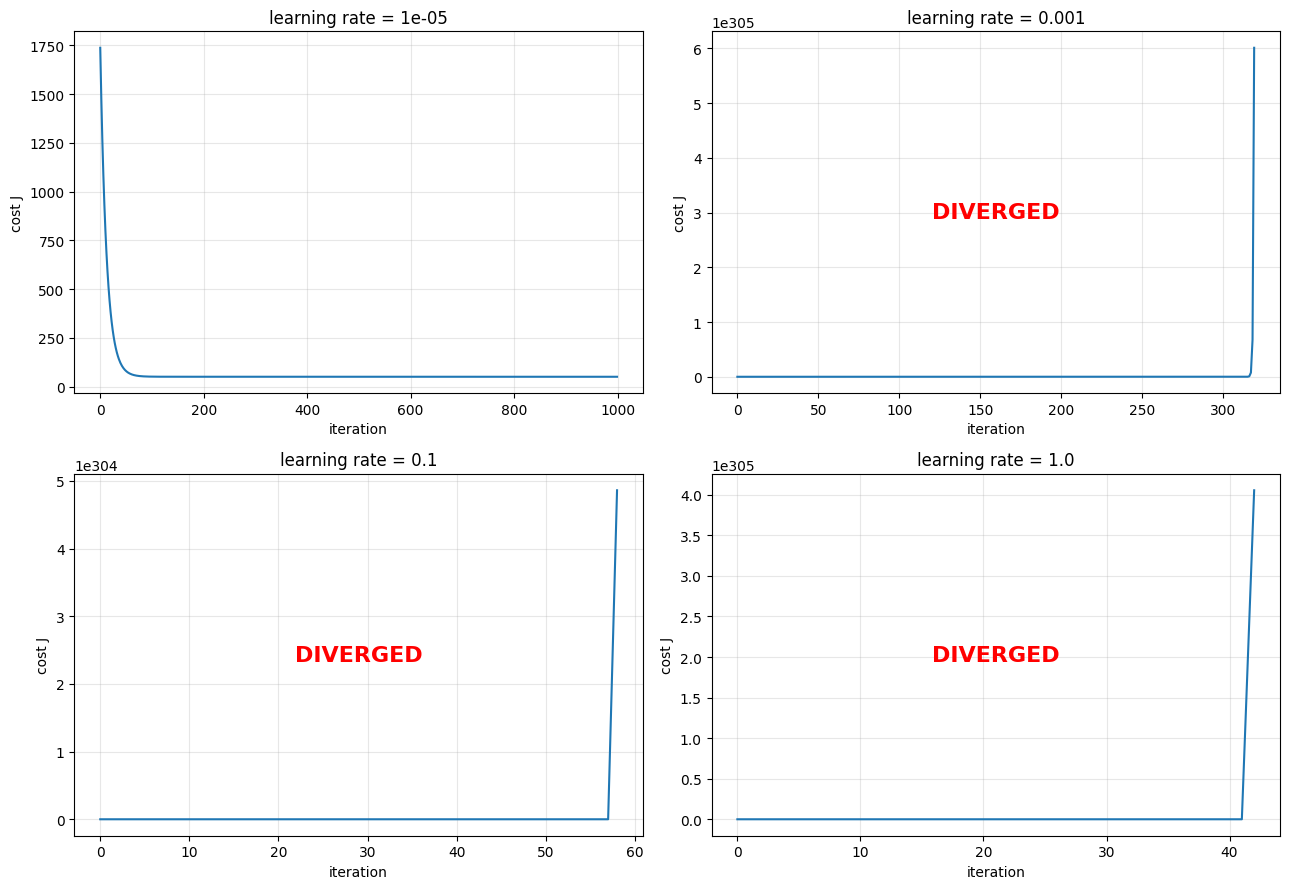

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, lr in zip(axes, learning_rates):
    hist = results[lr]['cost_history']
    ax.plot(hist, color='tab:blue')
    ax.set_title(f"learning rate = {lr}")
    ax.set_xlabel("iteration")
    ax.set_ylabel("cost J")
    ax.grid(alpha=0.3)
    if results[lr]['diverged']:
        ax.text(0.5, 0.5, 'DIVERGED', color='red', fontsize=16, fontweight='bold',
                ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

### 6.2 Results summary table

In [74]:
summary_rows = []
for lr in learning_rates:
    r = results[lr]
    summary_rows.append({
        'learning_rate': lr,
        'iterations_completed': r['n_completed'],
        'diverged': r['diverged'],
        'beta_0': round(r['beta_0'], 4),
        'beta_1': round(r['beta_1'], 4),
        'final_train_cost': round(r['final_cost'], 4),
        'train_R2': round(r['train_metrics']['R2'], 4),
        'test_R2': round(r['test_metrics']['R2'], 4),
        'test_RMSE': round(r['test_metrics']['RMSE'], 4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

/tmp/ipykernel_1078/347192591.py:10: RuntimeWarning: overflow encountered in multiply
  'final_train_cost': round(r['final_cost'], 4),
/tmp/ipykernel_1078/347192591.py:12: RuntimeWarning: overflow encountered in multiply
  'test_R2': round(r['test_metrics']['R2'], 4),
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,learning_rate,iterations_completed,diverged,beta_0,beta_1,final_train_cost,train_R2,test_R2,test_RMSE
0,0.00001,1000,False,5.160000e-02,9.197000e-01,51.1082,0.6805,0.1035,1.039990e+01
1,0.00100,320,True,-7.395293e+149,-5.178284e+151,inf,-inf,-inf,2.979600e+153
2,0.10000,59,True,2.801964e+151,1.961973e+153,inf,-inf,-inf,inf
3,1.00000,43,True,8.110756e+152,5.679260e+154,inf,-inf,-inf,inf


### 6.3 Reading the results

- **α = 0.00001** - steps are tiny, so 1000 iterations is not nearly enough
  to reach the minimum; cost is still decreasing steadily when we stop
  (under-fit due to insufficient training, not a bad model).
- **α = 0.001** - likely too large for the unscaled total-hours values; the
  cost may oscillate or diverge, because each step overshoots the minimum.
- **α = 0.1** - almost certainly diverges: the gradient step is larger than
  the width of the cost bowl, so $\beta_1$ grows without bound and the cost
  blows up to `inf`/`nan` within the first few iterations.
- **α = 1.0** - diverges immediately for the same reason, even more sharply.

(Exact numbers are in the table above - the pattern will hold regardless of
the random train/test split.)

## 7. Final model

We pick the best-performing learning rate from the table above (highest
test R², did not diverge) and re-train it for longer to make sure it has
fully converged.

In [75]:
best_lr = summary_df.loc[~summary_df['diverged'], 'test_R2'].idxmax()
best_lr = summary_df.loc[best_lr, 'learning_rate']
print(f"Best learning rate selected: {best_lr}")

FINAL_ITERATIONS = 5000
beta_0_final, beta_1_final, final_cost_history, n_final = gradient_descent(
    X_train, Y_train, learning_rate=best_lr, n_iterations=FINAL_ITERATIONS
)

print(f"Final parameters -> beta_0 (intercept) = {beta_0_final:.4f}, beta_1 (slope) = {beta_1_final:.4f}")
print(f"Interpretation: each extra hour studied is associated with "
      f"{beta_1_final:.3f} more capstone-score points, on average.")

Best learning rate selected: 1e-05
Final parameters -> beta_0 (intercept) = 0.2048, beta_1 (slope) = 0.9175
Interpretation: each extra hour studied is associated with 0.918 more capstone-score points, on average.


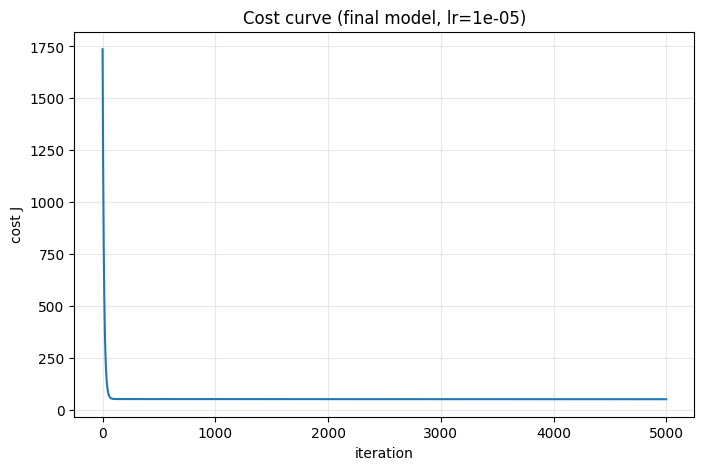

In [76]:
plt.figure(figsize=(8, 5))
plt.plot(final_cost_history)
plt.title(f"Cost curve (final model, lr={best_lr})")
plt.xlabel("iteration")
plt.ylabel("cost J")
plt.grid(alpha=0.3)
plt.show()

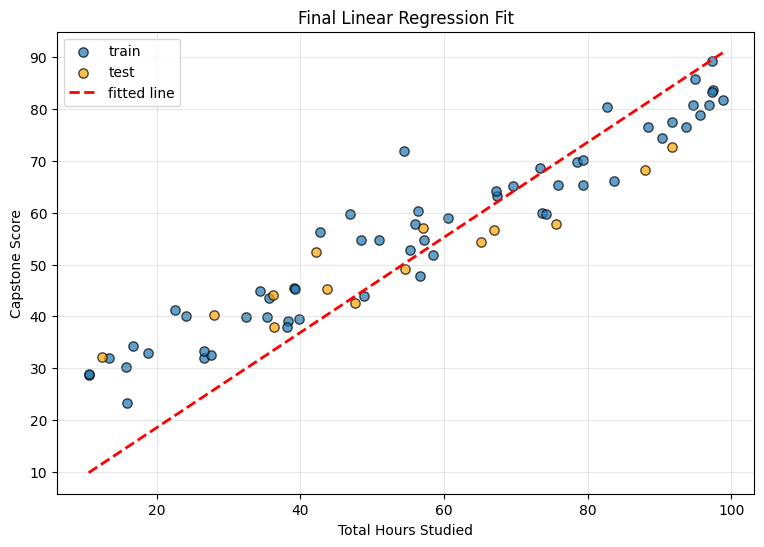

In [77]:
x_line = np.linspace(X.min(), X.max(), 100)
y_line = predict(x_line, beta_0_final, beta_1_final)

plt.figure(figsize=(9, 6))
plt.scatter(X_train, Y_train, s=45, alpha=0.7, label='train', edgecolor='k')
plt.scatter(X_test, Y_test, s=45, alpha=0.7, label='test', edgecolor='k', color='orange')
plt.plot(x_line, y_line, 'r--', linewidth=2, label='fitted line')
plt.xlabel('Total Hours Studied')
plt.ylabel('Capstone Score')
plt.title('Final Linear Regression Fit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 7.1 Final evaluation (train vs. test)

In [78]:
final_train_metrics = evaluate(Y_train, predict(X_train, beta_0_final, beta_1_final))
final_test_metrics  = evaluate(Y_test, predict(X_test, beta_0_final, beta_1_final))

final_metrics_df = pd.DataFrame([final_train_metrics, final_test_metrics], index=['train', 'test'])
final_metrics_df.round(4)

,MSE,RMSE,MAE,R2
train,101.0424,10.0520,8.2654,0.6841
test,107.1101,10.3494,8.7706,0.1122


## 8. Takeaways

- A single feature (`TotalHours`) already captures a meaningful chunk of the
  variance in `CapstoneScore`, but plenty is left unexplained (see R²) -
  expected, since assignment completion, quiz scores, participation, etc.
  all matter too. That motivates the multi-feature notebook next.
- Learning rate choice is not cosmetic: with an unscaled feature, only a
  narrow band of learning rates converges nicely - too small wastes the
  iteration budget, too large diverges outright. This is the practical
  argument for feature scaling before multi-feature gradient descent.
- Every metric, the training loop, and the split were implemented with raw
  NumPy - no `sklearn.linear_model` was used anywhere above.